===== BASIC INFO =====

Shape: (200, 5)

Data Types:
 CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows: 0


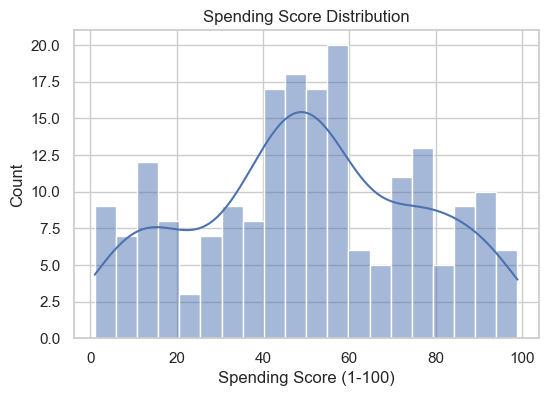

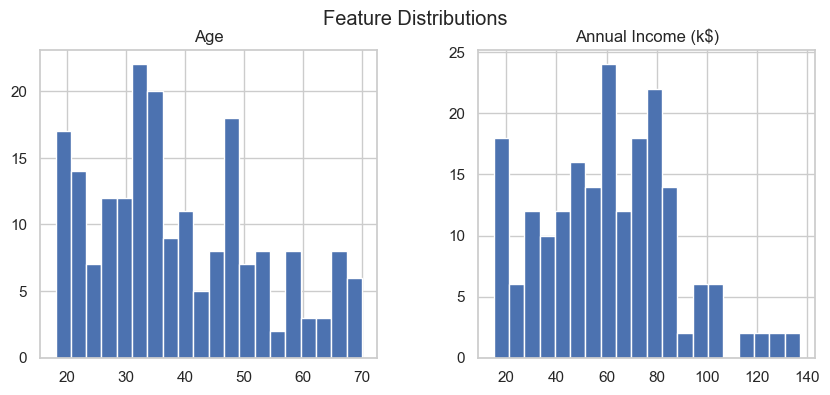

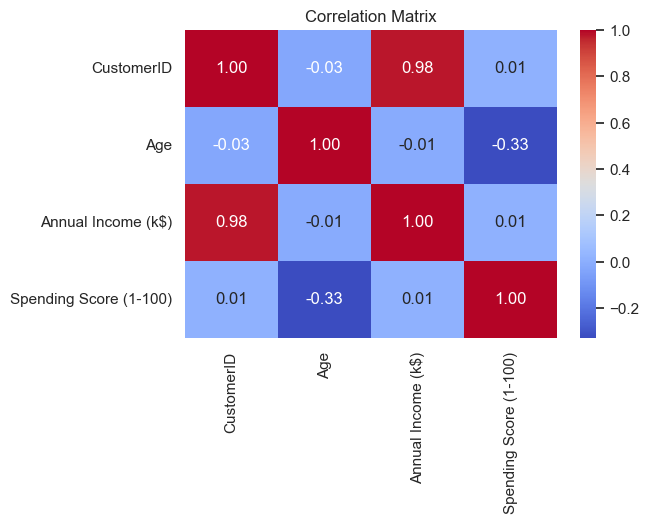


Train shape: (160, 3)
Test shape: (40, 3)

Scaled Sample:
 [[ 0.87077078  0.73027906 -0.24190423]
 [-1.14840785 -0.50042667  2.39455436]
 [ 0.87077078 -0.21084885 -0.8644014 ]]

Dummy Performance:
MAE: 18.666249999999998
RMSE: 23.56386269269111
R²: -0.12573113494444899

Linear Regression Performance:
MAE: 18.151395326685105
RMSE: 21.924259205438346
R²: 0.025478181600745997

Random Forest Performance:
MAE: 12.434466666666669
RMSE: 21.432106322673675
R²: 0.06873898826861369

===== MODEL COMPARISON =====

Dummy Regressor:
MAE: 18.666249999999998
RMSE: 23.56386269269111
R²: -0.12573113494444899

Linear Regression:
MAE: 18.151395326685105
RMSE: 21.924259205438346
R²: 0.025478181600745997

Random Forest:
MAE: 12.434466666666669
RMSE: 21.432106322673675
R²: 0.06873898826861369


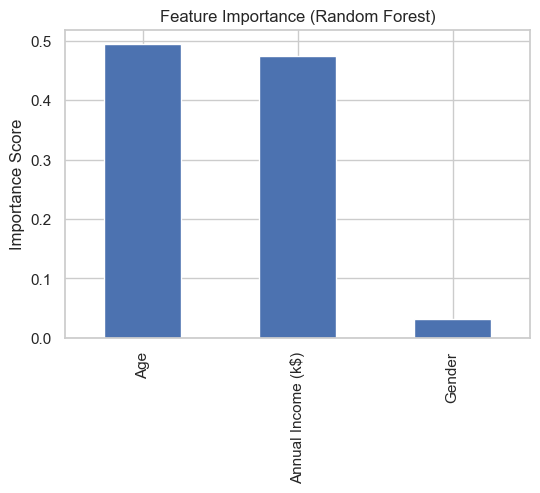


Feature Importances:
 Age                   0.494180
Annual Income (k$)    0.474412
Gender                0.031407
dtype: float64


In [2]:
# 0. IMPORTS & SETUP

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("Mall_Customers.csv")


# 1. BASIC DATA INSPECTION

print("===== BASIC INFO =====")

print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


# 2. TARGET DISTRIBUTION

plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()


# 3. FEATURE DISTRIBUTIONS

features = ['Age', 'Annual Income (k$)']

df[features].hist(figsize=(10,4), bins=20)
plt.suptitle("Feature Distributions")
plt.show()


# 4. CORRELATION MATRIX

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


# 5. PREPROCESSING

# Encode Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})


# 6. TRAIN-TEST SPLIT

X = df[['Gender', 'Age', 'Annual Income (k$)']]
y = df['Spending Score (1-100)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# 7. SCALING (for linear models)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled Sample:\n", X_train_scaled[:3])


# 8. MODELS

# ---------- 8.1 Dummy Regressor ----------
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled, y_train)

y_pred_dummy = dummy.predict(X_test_scaled)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy = r2_score(y_test, y_pred_dummy)

print("\nDummy Performance:")
print("MAE:", mae_dummy)
print("RMSE:", rmse_dummy)
print("R²:", r2_dummy)


# ---------- 8.2 Linear Regression ----------
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\nLinear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)


# ---------- 8.3 Random Forest ----------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)   # No scaling needed

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)


# 9. MODEL COMPARISON

print("\n===== MODEL COMPARISON =====")

print("\nDummy Regressor:")
print("MAE:", mae_dummy)
print("RMSE:", rmse_dummy)
print("R²:", r2_dummy)

print("\nLinear Regression:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

print("\nRandom Forest:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)


# 10. FEATURE IMPORTANCE

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

print("\nFeature Importances:\n", importances)